Notebook to create and save simulated burst(s)

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from astropy.constants import c
from fitburst.analysis.model import SpectrumModeler

In [2]:
DATA_DIR = '/scratch/abernier/pulsar_data/full_stokes/2022_CHIME_B2111+46'
SETTINGS = 'bands6_timeavg391_300files_start160'
DATA_FILE = f'{DATA_DIR}/20220826T064420Z_{SETTINGS}.npz'
SAVE_DIR = "/scratch/abernier/pulsar_data/full_stokes/sim_bursts"

S_LABELS = ['I', 'Q', 'U', 'V']

# Open pulsar data

In [3]:
# Load data
full_stokes_npz = np.load(DATA_FILE)
full_stokes = full_stokes_npz['full_stokes']   # shape (Nstokes, Ntimes, Nfreqs)
time = full_stokes_npz['time']
freq = full_stokes_npz['freq']
t_unit = 's'

# Simulate Burst 

In [4]:
# --- Model parameters ---
num_bursts = 2  # number of bursts to model
TIME_TRUE = [10, 25]  # true arrival times of the bursts (unit is given by whatever unit the time axis has)
burst_amp_exp = [0., 0.2]  # Base-10 exponent of amplitude for bursts
burst_amp = [10**amp for amp in burst_amp_exp]  # Convert to amplitude
lower_peak_ti = TIME_TRUE[np.argmin(burst_amp_exp)]  # time of lower peak

# Burst parameters
burst_params_1 = {
    "amplitude"            : [burst_amp_exp[0]],  # overall signal amplitude
    "arrival_time"         : [TIME_TRUE[0]],  # when burst starts
    "burst_width"          : [0.04],  # width in time (eg. 0.5 will be 0.5 in whatever unit the given time axis has)
    "dm"                   : [0.],
    "dm_index"             : [-2.],  # don't touch 
    "ref_freq"             : [500.],  # ref freq for arrival-time and power-law param estimates
    "scattering_index"     : [-4.],  # index of the scattering timescale, don't touch
    "scattering_timescale" : [0.],  # don't touch
    "spectral_index"       : [0.],  # how flat across frequency
    "spectral_running"     : [-10.],  # additional curvature
}
burst_params_2 = {
    "amplitude"            : [burst_amp_exp[1]],  # overall signal amplitude
    "arrival_time"         : [TIME_TRUE[1]],  # when burst starts
    "burst_width"          : [0.01],  # width in time values
    "dm"                   : [0.],
    "dm_index"             : [ -2.],  # don't touch 
    "ref_freq"             : [700],  # ref freq for arrival-time and power-law param estimates
    "scattering_index"     : [-4.],  # index of the scattering timescale, don't touch
    "scattering_timescale" : [0.],  # don't touch
    "spectral_index"       : [0.],  # how flat across frequency
    "spectral_running"     : [-10.],  # additional curvature
}
burst_params = [burst_params_1, burst_params_2]


# --- Other parameters ---
# Pol fractions
pol_frac_linear = [0.7, 0.4]  # can also have diff fractions for U and Q
pol_frac_circular = 0.

# Intrinsic polarization angle
psi_0 = 30  # [deg]
psi_0_rad = np.radians(psi_0)  # [rad]

# RM
RM_true = [-120,500]  # [rad/m^2] 

In [5]:
# --- Create dict of all parameters --
params = {
    "num_bursts": num_bursts,
    "TIME_TRUE": TIME_TRUE,
    "burst_amp_exp": burst_amp_exp, 
    "burst_amp": burst_amp,
    "lower_peak_ti": lower_peak_ti,
    "burst_params": burst_params,
    "pol_frac_linear": pol_frac_linear,
    "pol_frac_circular": pol_frac_circular,
    "psi_0_rad": psi_0_rad,
    "RM_true": RM_true
}

In [6]:
# --- Get Stokes I ---
I_components = np.empty((num_bursts, len(freq), len(time)))  # (Nbursts, Nfreqs, Ntimes)

for i in range(num_bursts):
    # Create model & update parameters
    model = SpectrumModeler(freq, time)
    model.update_parameters(burst_params[i])

    # Get model spectrum (Stokes I)
    I_components[i] = model.compute_model()  # (Nfreqs, Ntimes)
    
# Get array of Stokes I (with all bursts)
I_sim = np.sum(I_components, axis=0)  # (Nfreqs, Ntimes)

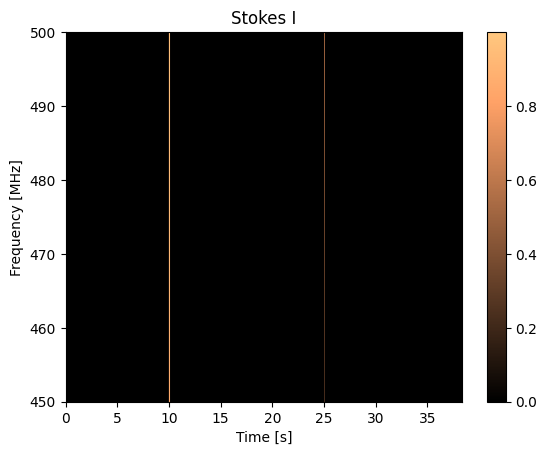

In [7]:
# Plot model
fig, ax = plt.subplots()

extent = (time[0], time[-1], freq[0], freq[-1])
im = ax.imshow(I_sim, interpolation='nearest', origin='lower', aspect='auto', extent=extent, cmap='copper')

fig.colorbar(im, ax=ax, label='')
ax.set_xlabel(f'Time [{t_unit}]')
ax.set_ylabel('Frequency [MHz]')
ax.set_title(f'Stokes I')
plt.show()

In [8]:
# --- Create other Stokes parameters ---
# Arrays to fill, shapes (Nbursts, Nfreqs, Ntimes)
Q_components = np.zeros_like(I_components) 
U_components = np.zeros_like(I_components)
V_sim = np.zeros_like(I_components)

for i in range(num_bursts):
    Q_components[i] = I_components[i] * pol_frac_linear[i] * np.cos(2 * psi_0_rad)  # Q = I p_lin cos(2*psi_0)
    U_components[i] = I_components[i] * pol_frac_linear[i] * np.sin(2 * psi_0_rad)  # U = I p_lin sin(2*psi_0)
V_sim = I_sim * pol_frac_circular  # V = I p_circ

In [9]:
def apply_rm(I, Q, U, RM, freq):
    """
    Apply rotation measure to Stokes Q and U.

    Return the rotated Q and U parameters.

    Parameters
    ----------
    I : Stokes I intensity (shape: [Nfreqs, Ntimes]).
    Q : Stokes Q parameter (shape: [Nfreqs, Ntimes]).
    U : Stokes U parameter (shape: [Nfreqs, Ntimes]).
    RM : Rotation measure (shape: [Nfreqs]). In rad/m^2.
    freq : Frequency array (shape: [Nfreqs]). In MHz.
    """
    # Change zeros to NaN in off-burst region
    mask = (I < 1e-7)  # approx that off-burst is where 1e-7
    Q[mask] = np.nan
    U[mask] = np.nan
    # plot_stokes([I, Q, U, V], suptitle='After masking off-burst region')

    # dpsi = 2RM * lambda^2
    lambda_sq = (c.value/(freq*1e6))**2  # shape (Nfreqs)
    dpsi = 2 * RM * lambda_sq

    # Rotate Q and U
    cos_dpsi = np.cos(dpsi)[:, np.newaxis]  # shape (Nfreqs, 1)
    sin_dpsi = np.sin(dpsi)[:, np.newaxis]  # shape (Nfreqs, 1)

    Q_rot = Q*cos_dpsi - U*sin_dpsi
    U_rot = Q*sin_dpsi + U*cos_dpsi

    # Switch back NaNs to 0
    Q_rot = np.nan_to_num(Q_rot)
    U_rot = np.nan_to_num(U_rot)

    return Q_rot, U_rot

In [10]:
# Arrays to fill
Q_rot_components = np.zeros_like(Q_components)
U_rot_components = np.zeros_like(U_components)

# Apply RM to each burst's Q and U components
for i in range(num_bursts):
    Q_rot_components[i], U_rot_components[i] = apply_rm(
        I_components[i], Q_components[i], U_components[i], RM_true[i], freq
    )

# Combine rotated components into arrays of shape (Nfreqs, Ntimes)
# **Note: opposite shape from the loaded data
Q_rot = np.sum(Q_rot_components, axis=0)
U_rot = np.sum(U_rot_components, axis=0)

In [11]:
# Get full array to save
full_stokes_sim = np.array([I_sim.T, Q_rot.T, U_rot.T, V_sim.T])  # shape (Nstokes, Ntimes, Nfreqs)

# Save data as .npz file
# SAVE_PATH = f'{SAVE_DIR}/sim_{SETTINGS}.npz'
# os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
# np.savez_compressed(SAVE_PATH, 
#                     full_stokes=full_stokes_sim, 
#                     time=time,
#                     freq=freq, 
#                     params=params)

# Look at data

In [ ]:
# The RFI flagging and normalization of the data is handled in the search pipeline
# this is just to get a first look at what it'll look liek to make sure the data
# looks acceptable

In [12]:
def flag_rfi_manual(ranges, freqs):
    """
    ranges : list of tuples
        list of (start,end) frequencies to mask
    """
    channel_mask_manual = np.full(len(freqs), False)
    
    for (start,end) in ranges:
        # Check that freqs to mask are at least particlaly contained in the frequency array
        if start > freq[-1] or end < freqs[0]:  # completely out of range
            continue

        if start == end:
            end += freqs[1] - freqs[0]

        mask = (start <= freqs) & (freqs <= end)
        channel_mask_manual |= mask  

    return channel_mask_manual
    

def get_rfi_mask(intensity_array, mean_treshhold=2, std_threshold=5, ranges=None, freqs=None):
    """
    Flag frequency channels with anomalous statistics across time, such as unusually high
    mean or standard deviation, which may indicate RFI. Returns a boolean mask.
    
    Parameters
    ----------
    intensity_array : np.ndarray
        Normalized intensity data with shape (Ntimes, Nfreqs), where each column is a frequency channel.
    mean_threshold : float
        Threshold for the absolute value of the mean. Channels with |mean| > mean_threshold are flagged.
    std_threshold : float
        Threshold for the standard deviation. Channels with std > std_threshold are flagged.
    
    Returns
    -------
    channel_mask : np.ndarray
        Boolean array of shape (Nfreqs,) where True indicates a flagged (to be masked) frequency channel.
    """

    # Mean and std per frequency channel (avg across time)
    mean_per_channel = np.nanmean(intensity_array, axis=0)
    std_per_channel = np.nanstd(intensity_array, axis=0)

    # Normalize & compare channel means
    means_norm = (mean_per_channel - np.mean(mean_per_channel)) / np.std(mean_per_channel)
    channel_mask_mean = np.abs(means_norm) > mean_treshhold

    # Normalize & compare channel stds
    stds_norm = (std_per_channel - np.mean(std_per_channel)) / np.std(std_per_channel)
    channel_mask_std = np.abs(stds_norm) > std_threshold

    # Manually mask some channels
    cond_manual = (ranges is not None) and (freqs is not None)
    if cond_manual:
        channel_mask_manual = flag_rfi_manual(ranges, freqs)
    
    # Combine masks
    if cond_manual:
        channel_mask = channel_mask_mean | channel_mask_std | channel_mask_manual
    else:
        channel_mask = channel_mask_mean | channel_mask_std

    return channel_mask


def normalize_data(data_array):
    """
    Normalize data by subtracting the mean and dividing by the standard deviation,
    computed per frequency channel (over time) for each Stokes parameter.

    Parameters
    ----------
    data_array : np.ndarray
        Array of data to normalize (shape: [Nstokes, Ntimes, Nfreqs]).

    Returns
    -------
    data_normalized : np.ndarray
        Normalized array of the same shape
    """
    
    mean_per_channel = np.nanmean(data_array, axis=1, keepdims=True)
    std_per_channel = np.nanstd(data_array, axis=1, keepdims=True)
    
    return (data_array - mean_per_channel) / std_per_channel

In [13]:
# Define parameters 
RFI_MEAN_THRESHOLD=1.7
RFI_STD_THRESHOLD=1.3
RFI_RANGES = [(529,535), (483, 483), (452,452)]  # in MHz

# Get RFI mask using intensity data
rfi_mask = get_rfi_mask(full_stokes[0], 
                        mean_treshhold=RFI_MEAN_THRESHOLD, 
                        std_threshold=RFI_STD_THRESHOLD,
                        ranges=RFI_RANGES, freqs=freq)

# Normalize & mask RFI channels
stokes_norm_masked = normalize_data(full_stokes.copy())
stokes_norm_masked[:,:,rfi_mask] = np.nan

In [14]:
# Add simulated bursts to real data
full_stokes_new = full_stokes_sim + stokes_norm_masked

In [15]:
# --- 4-panels plot function ---
def plot_stokes(data_array, freq, time, t_unit='ms', suptitle='', 
                rfi_masked=None, height_ratios=[1, 3], cbar_lim=None, 
                sim=False, save_name=None, save_loc=None):
    """
    Plot Stokes parameters I, Q, U, V in a 2x2 grid.

    Parameters
    ----------
    data_array : Array of the 4 Stokes parameters in the order I, Q, U, V. Shape (Nstokes, Ntimes, Nfreqs).
    freq : Frequency array (MHz).
    time : Time array (in t_unit).
    t_unit : Defines the unit for the time array (e.g., 'ms', 's').
    suptitle : Title for the entire figure.
    rfi_masked : List of RFI channels to highlight in red.
    height_ratios : Height ratio of the top/bottom panels for each Stokes subplot.
    cbar_lim : Stokes data array to use to set the cbar limits. When None, data_array is used.
    """
    
    # Figure info
    fig = plt.figure(figsize=(10, 11), dpi=200)
    outer = gridspec.GridSpec(2, 2, hspace=0.15, wspace=0.35)  # 2x2 grid for Stokes parameters
    extent = (time[0], time[-1], freq[0], freq[-1])
    plt.suptitle(suptitle)

    # Go through all Stokes parameters
    for i, param in enumerate(S_LABELS):
        data_plot = data_array[i]
        row = i // 2
        col = i % 2

        # Define inner grid for timeseries and Stokes parameter plots
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,  # 2 rows: timeseries + stokes
            subplot_spec=outer[row, col],
            height_ratios=height_ratios,
            hspace=0.0  # no space between timeseries and stokes
        )

        # Add subplots
        timeseries_ax = fig.add_subplot(inner[0])
        stokes_ax = fig.add_subplot(inner[1], sharex=timeseries_ax)

        # --- Add timeseries plot ---
        timeseries = np.nanmean(data_plot, axis=1)  # Average over frequency
        timeseries_ax.scatter(time, timeseries, color='black', s=1)
        timeseries_ax.set_title(f'Stokes {param}')
        timeseries_ax.tick_params(length=0, labelbottom=False, labelleft=False)

        # --- Add Stokes parameter plot ---
        # Colorbar limits
        if cbar_lim is None:
            cbar_lim = data_plot
        vmin = np.nanpercentile(cbar_lim, 5)
        vmax = np.nanpercentile(cbar_lim, 95)
        linear = plt.cm.colors.Normalize(vmin=vmin, vmax=vmax)
        if sim:
            linear = plt.cm.colors.Normalize()
        # Plot data
        im = stokes_ax.imshow(data_plot.T, 
                       origin='lower', 
                       aspect='auto', 
                       extent=extent, 
                       cmap='viridis',
                       norm=linear
                       )
        
        # --- Colorbar ---
        anchor_height = 0.39 if row==0 else 0.
        cbar = fig.colorbar(im, ax=(timeseries_ax, stokes_ax), pad=0.05, 
                        shrink=height_ratios[1]/np.sum(height_ratios) * 1.06, 
                        anchor=(1.65, anchor_height)
                        )
        # cbar.set_label(cbar_label)
        
        # --- Highlight RFI channels ---
        # if rfi_masked is not None:
        #     add_rfi_rectangles(stokes_ax, rfi_masked, freq=freq, time=time)

        # --- Axes labels ---
        if i >= 2:
            stokes_ax.set_xlabel(f'Time [{t_unit}]')
        if i % 2 == 0:
            stokes_ax.set_ylabel('Frequency [MHz]')

    
    plt.subplots_adjust(top=0.93) 

    plt.show()

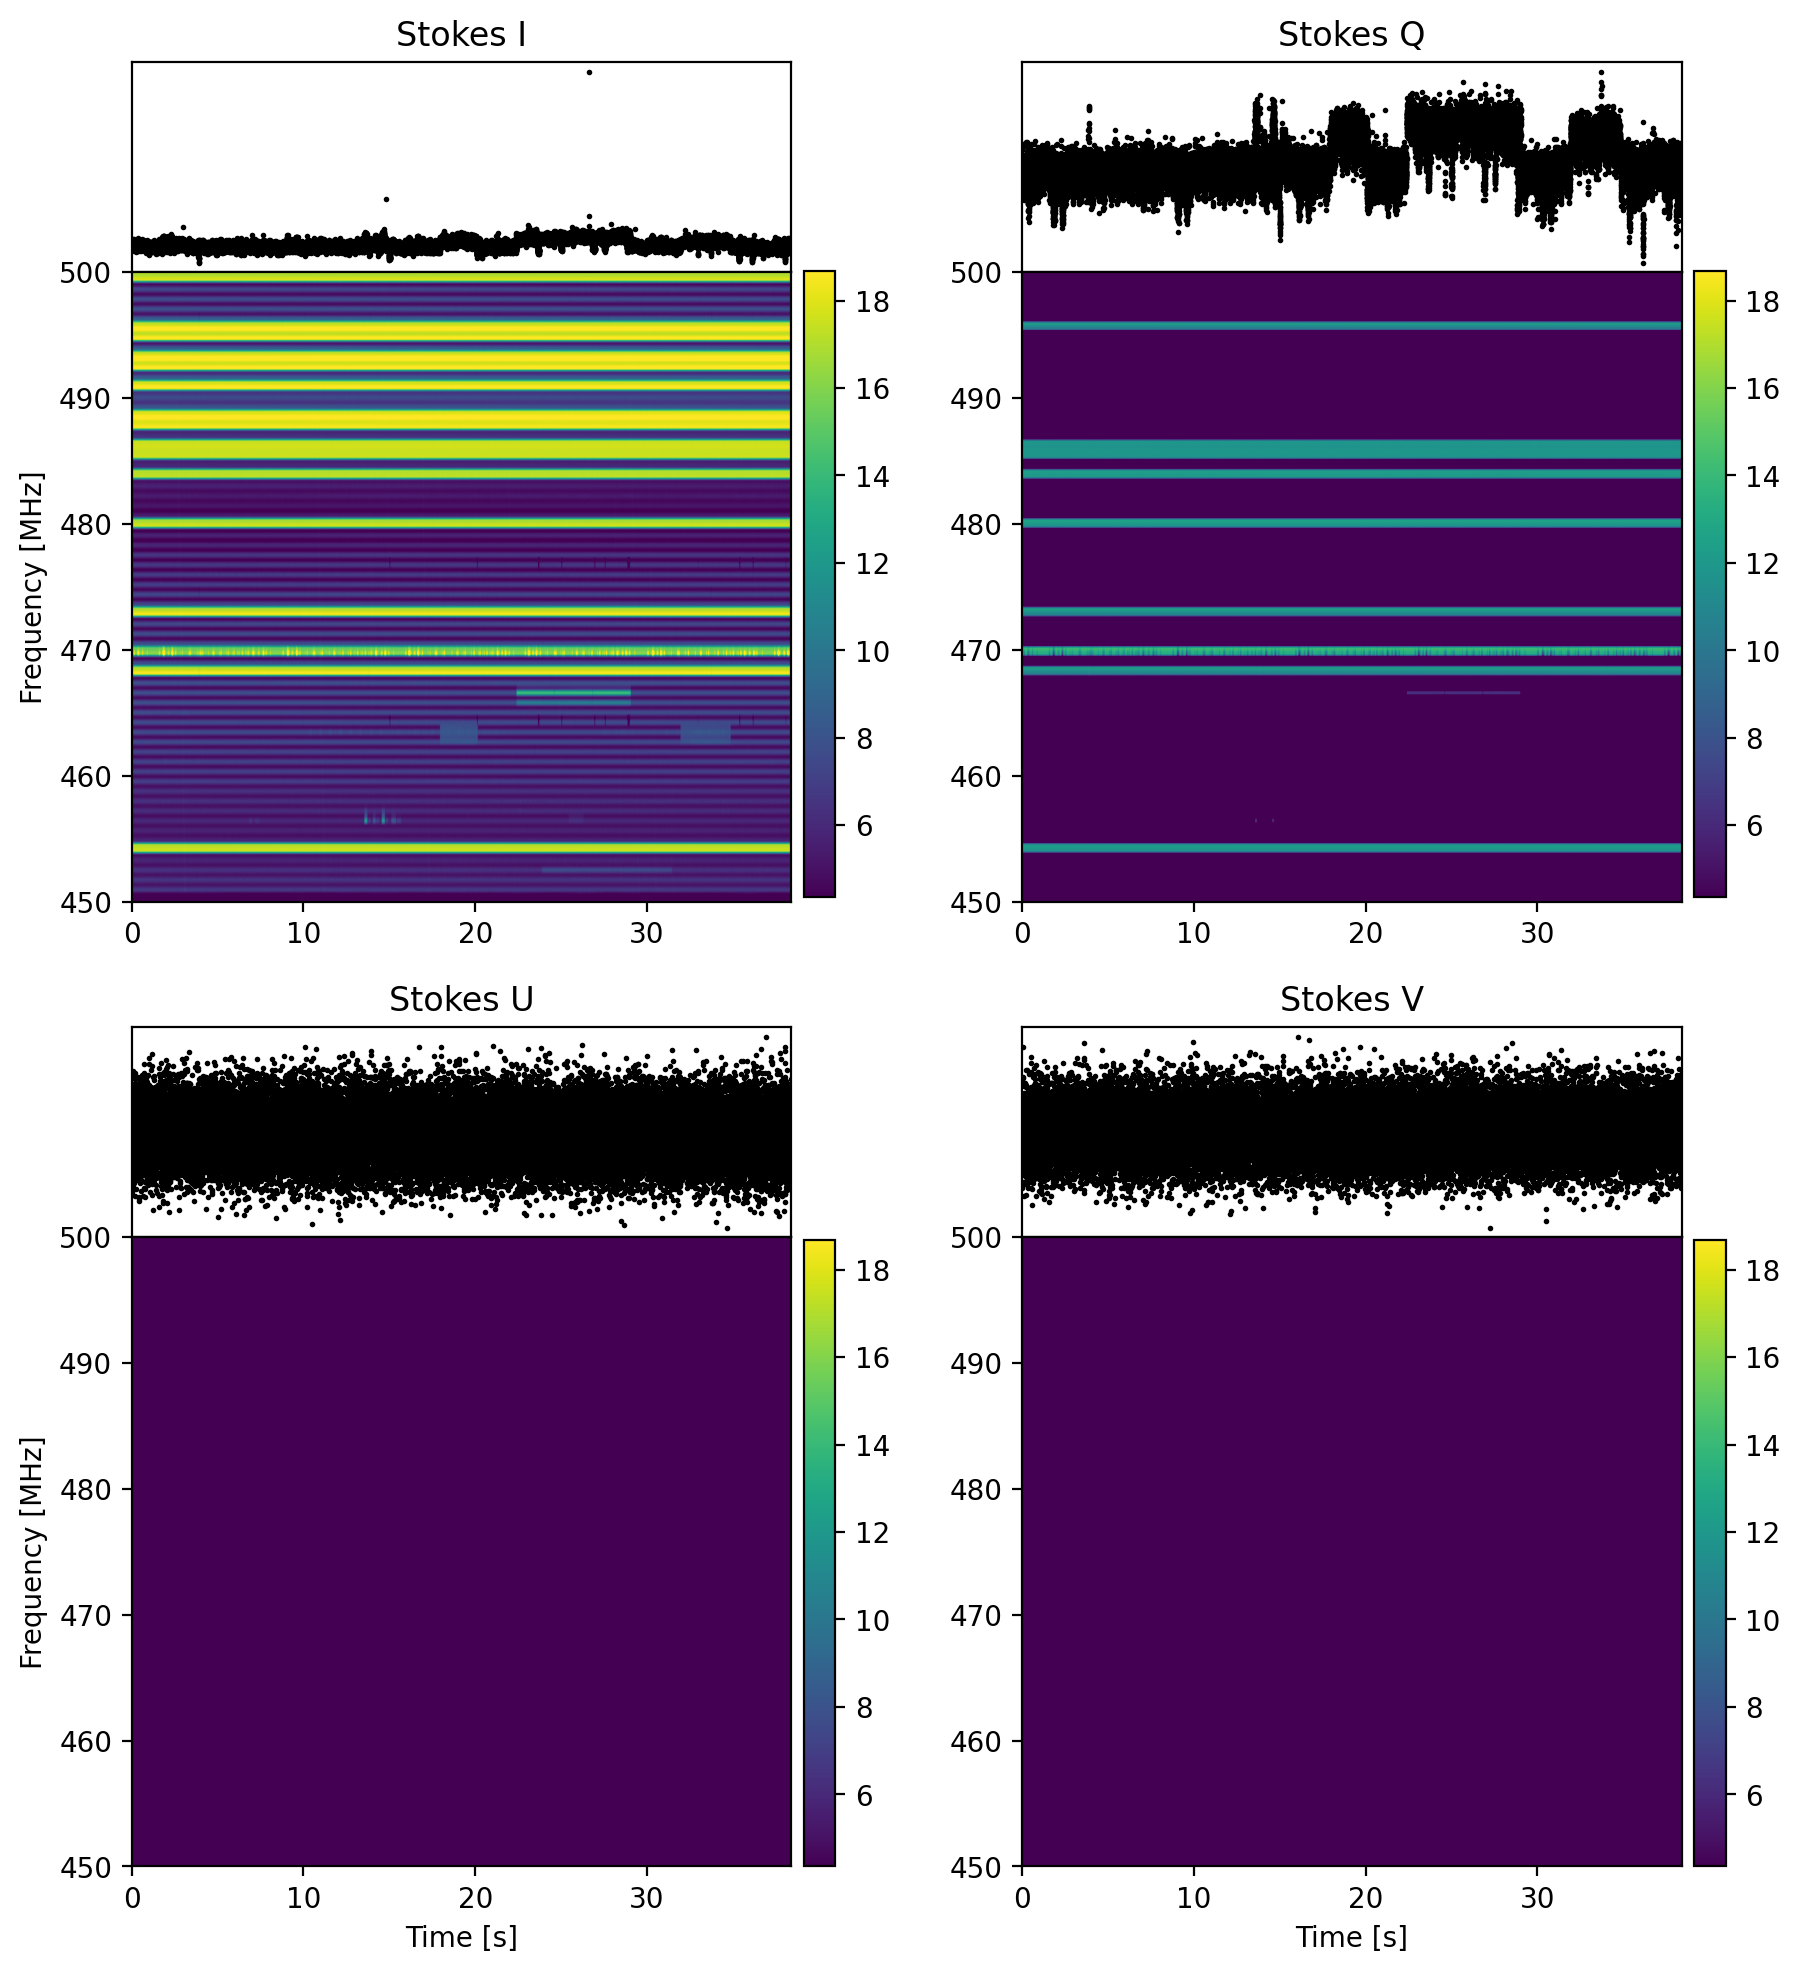

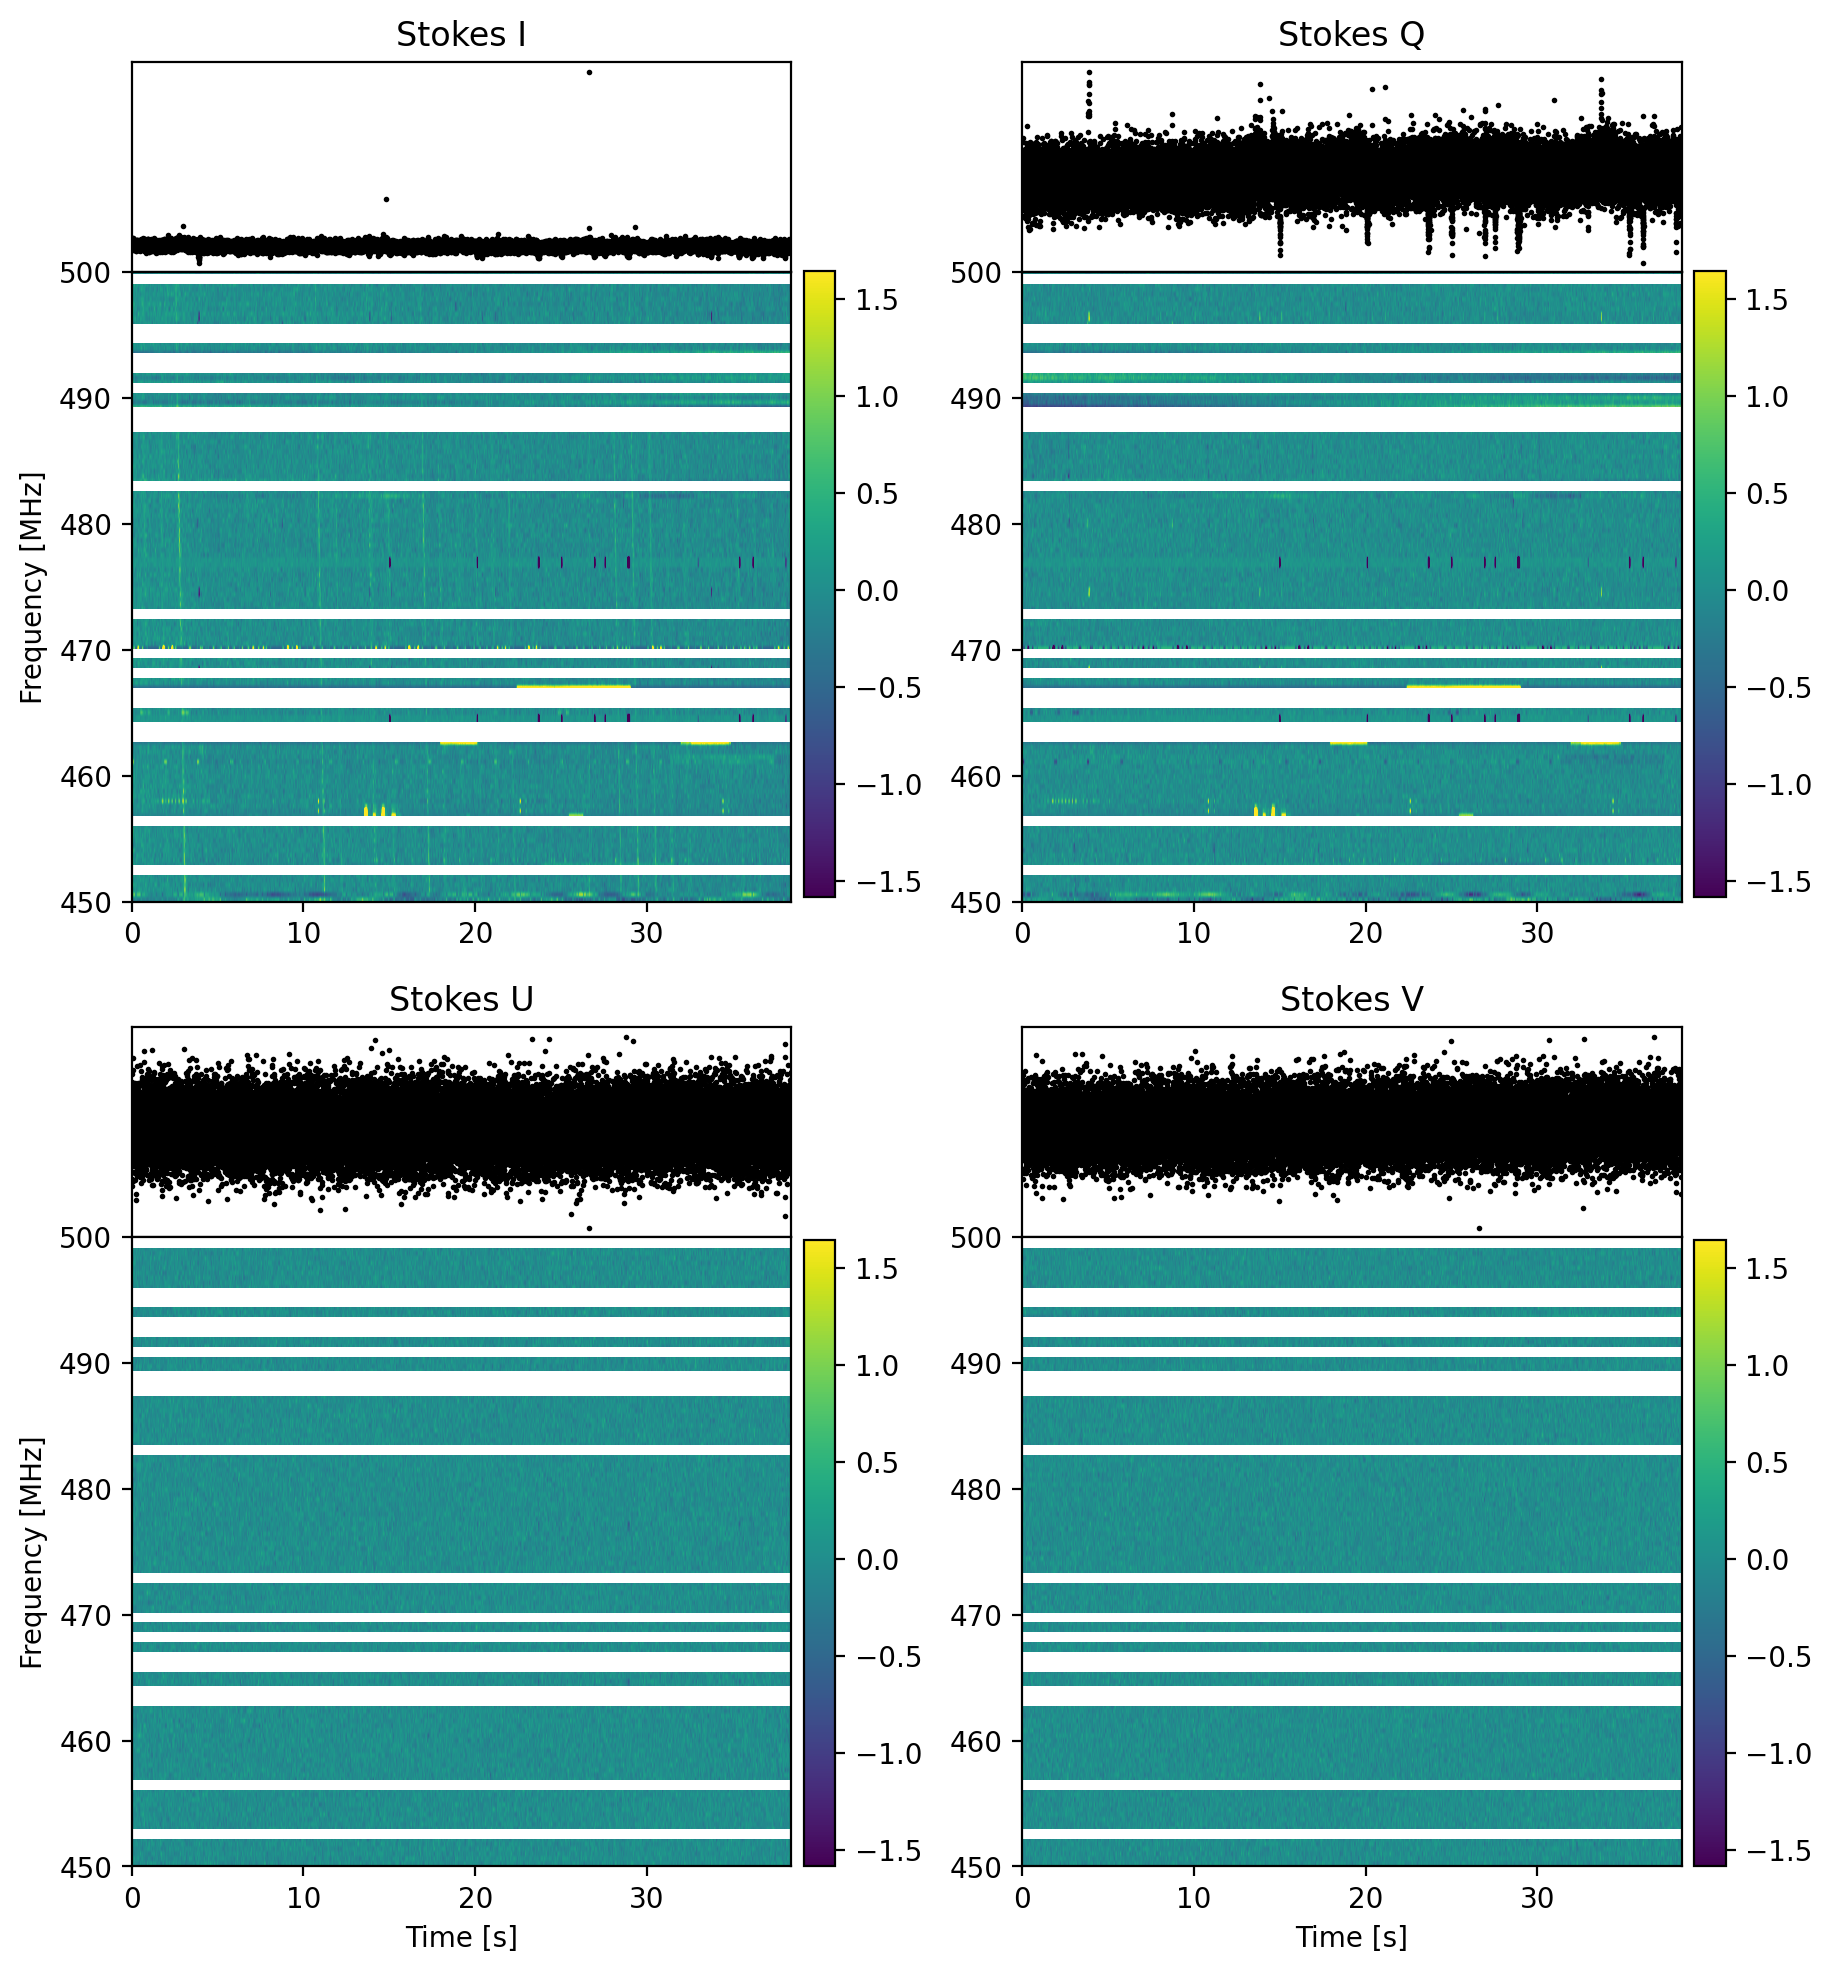

In [16]:
# Plot loaded data
plot_stokes(full_stokes, freq, time, t_unit='s')
plot_stokes(stokes_norm_masked, freq, time, t_unit='s')

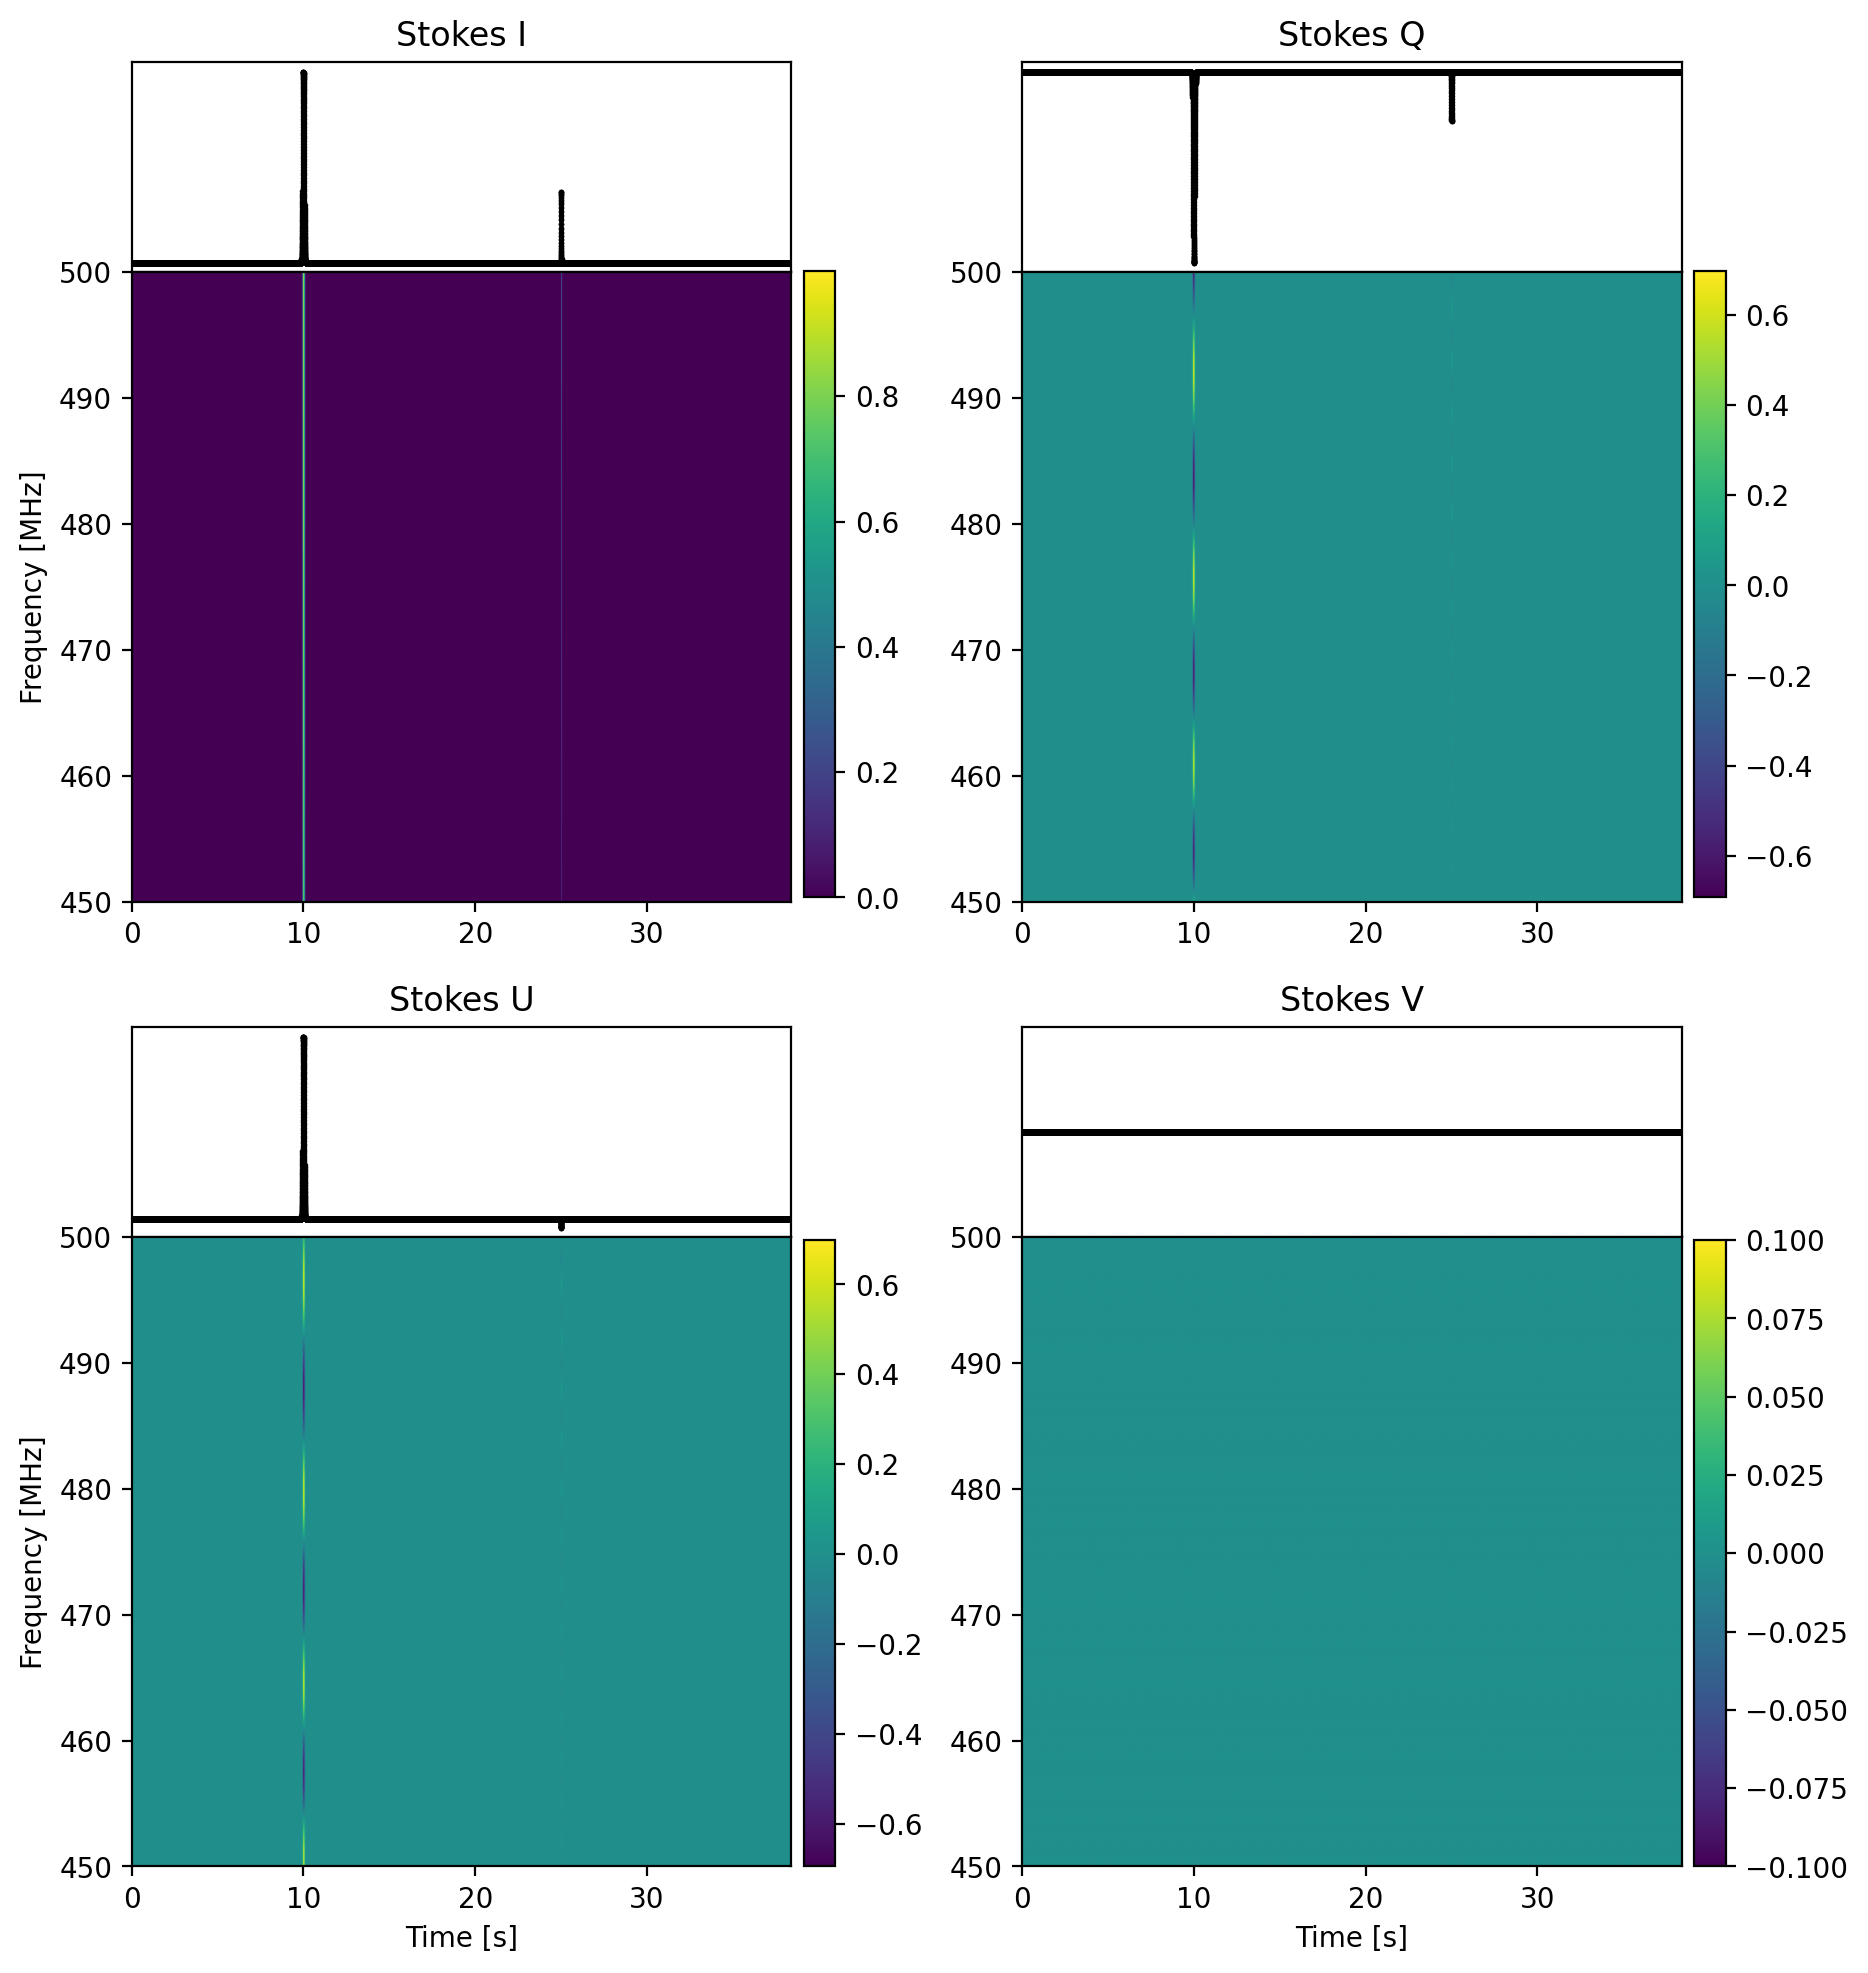

In [18]:
# Plot simulated data
plot_stokes(full_stokes_sim, freq, time, t_unit='s', sim=True)

In [ ]:
# Plot final saved data
plot_stokes(full_stokes_new, freq, time, t_unit='s')